In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\tript\OneDrive\Desktop\internsip\03_aum_by_fund_house.csv")

In [4]:
df

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
...,...,...,...,...,...
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
88,2025-12-31,Mirae Asset MF,2.90,290000,56


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [6]:
df.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.6+ KB


In [9]:
df.isnull().sum()

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,date,aum_lakh_crore,aum_crore,num_schemes
count,90,90.000000,9.000000e+01,90.000000
mean,2024-02-19 10:40:00,4.352889,4.352889e+05,152.200000
min,2022-03-31 00:00:00,1.050000,1.050000e+05,56.000000
25%,2023-03-31 00:00:00,2.525000,2.525000e+05,95.000000
50%,2024-03-31 00:00:00,3.450000,3.450000e+05,172.500000
75%,2024-12-31 00:00:00,5.675000,5.675000e+05,195.000000
max,2025-12-31 00:00:00,12.500000,1.250000e+06,216.000000
std,NaN,2.734328,2.734328e+05,52.108832


In [12]:
df.duplicated().sum()

np.int64(0)

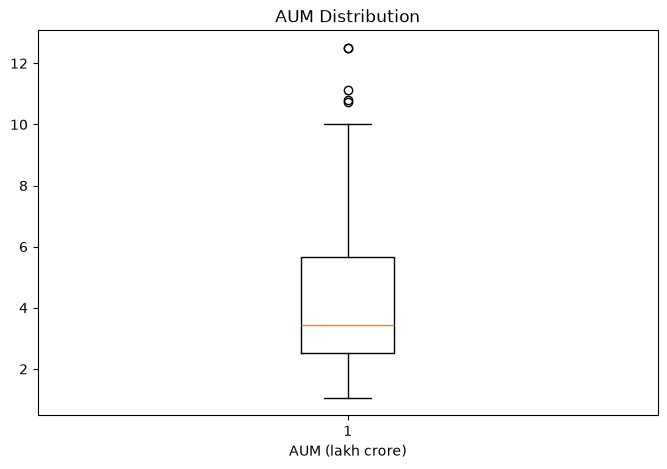

In [ ]:
import matplotlib.pyplot as plt

col = "aum_lakh_crore"
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
filtered_df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

plt.figure(figsize=(8, 5))
plt.boxplot(filtered_df[col])
plt.title("AUM Distribution (IQR-filtered)")
plt.ylabel("AUM (lakh crore)")
plt.show()

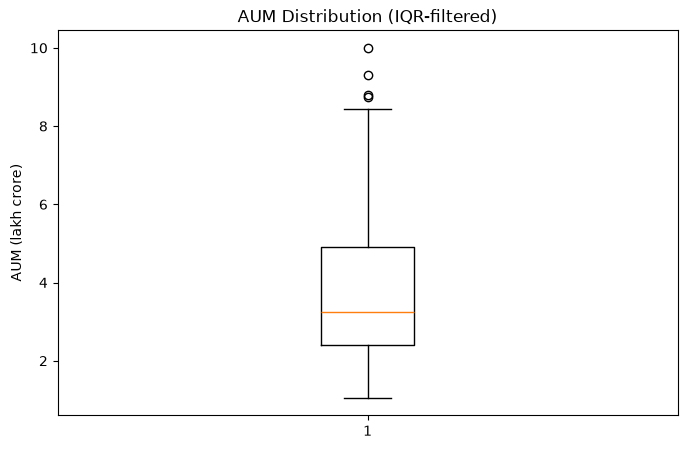

In [15]:
import matplotlib.pyplot as plt

col = "aum_lakh_crore"
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
filtered_df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

plt.figure(figsize=(8, 5))
plt.boxplot(filtered_df[col])
plt.title("AUM Distribution (IQR-filtered)")
plt.ylabel("AUM (lakh crore)")
plt.show()

In [16]:
sorted_df = filtered_df.sort_values(by="aum_lakh_crore", ascending=False)
sorted_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
71,2025-03-31,ICICI Prudential MF,8.80,880000,216
61,2024-12-31,ICICI Prudential MF,8.74,874000,216
30,2023-09-30,SBI Mutual Fund,8.45,845000,186


In [17]:
df.to_csv("03_aum_by_fund_house_clean.csv", index=False)